In [2]:
import numpy as np
import matplotlib as mpl
import pandas as pd
import matplotlib.pyplot as plt
import math

In [3]:
def compareVectors(control_filename, filtered_filename, num_frames, digits=4):
    '''
    A function which will, for each frame of a video clip analyzed in PIVlab and exported as an ASCII text file, give the percent of vectors that
    have been replaced/interpolated using validation filters. Assuming reasonable filters (that is up to the user), this will give the amount of
    usable vectors after removing noise or interpolating missing values.

    Ensure that all files for filtered/unfiltered data are in the same folder!
    THIS WILL ONLY WORK FOR .TXT FILES!
    Also, as much as it is the most annoying thing ever, if your path copies with backslashes (\) you will need to manually change them to
    forward slashes (/). I know. Python throws a whole fit about it.

    NOTE: Assumes the following settings on export...
    Delimiter: comma
    ONLY "add column headers" on

    Inputs:
    
    str control_filename: 
    TLDR: The file path of a .txt file from your PIVlab export WITHOUT the frame number and the .txt suffix.
    When exporting multiple frames, the files will be named something_0001, something_002, et cetera.
    This string will take the WHOLE PATH (as in, from the C:user/documents etc etc) UP UNTIL the numbers at the end. So, a file may look something like
    C:/user/downloads/folder/something_0001.txt

    str filtered_filename: Same as control_filename, but for your FILTERED data (after applying validation)

    int num_frames: How many frames are there?

    (optional) int digits: The string of numbers at the end of your file names should not be included in filename. How many 'digits' are there 
    of the string of numbers at the end? i.e, for file data_0001, digits=4. For file data_001, digits=3.

    Outputs:

    An array of float64 values representing the Valid Detection Probability (VDP) of the filtered vectors as a percent, 
    in chronological order of the frames.

    In other words, it calculates how many vectors (excluding vectors within the mask, which will always be NaN) remain unchanged after applying
    validation filters. This is useful for getting an idea of how noisy your data is or whether you're overfiltering it. Ideally, the VDP should be
    above 90% for a given frame. In other words, you shouldn't filter out/interpolate more than 10% of your vectors per frame.

    '''
    valid_vector_percent=np.zeros(num_frames)
    counter = np.arange(num_frames)

    #for each frame, calculate VDP
    for i in counter:
        numstring = str(i+1)
        while len(numstring)<digits:
            numstring = "0"+numstring
        control = pd.read_csv(control_filename+numstring+".txt")
        filtered = pd.read_csv(filtered_filename+numstring+".txt")
        num_vectors = len(control[control.columns[1]])
        isTheSame = [False]*num_vectors
        isMask = [False]*num_vectors

        #Has the vector been interpolated? Is it part of the mask?
        for j in np.arange(num_vectors):
            isTheSame[j] = (str(control[control.columns[2]][j]) == str(filtered[filtered.columns[2]][j])) and (str(control[control.columns[3]][j]) == str(filtered[filtered.columns[3]][j]))
            isMask[j] = np.isnan(filtered[filtered.columns[2]][j]) and np.isnan(filtered[filtered.columns[3]][j])
            
        numSame = np.cumsum(isTheSame)[len(np.cumsum(isTheSame))-1]
        numMasked = np.cumsum(isMask)[len(np.cumsum(isMask))-1]

        #How many of the non-mask vectors remain as their original values?
        valid_vector_percent[i] = (numSame-numMasked)/(num_vectors-numMasked)*100
    return valid_vector_percent

<>:9: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
<>:9: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
C:\Users\oksan\AppData\Local\Temp\ipykernel_15328\480969531.py:9: SyntaxWarning: "\)" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\)"? A raw string is also an option.
  Also, as much as it is the most annoying thing ever, if your path copies with backslashes (\) you will need to manually change them to


In [5]:
def histogramVDP(control_filename, filtered_filename, num_frames, digits=4):
    '''
    Plots a histogram of VDP (valid detection probability) values, along with a bar at 90% to show if the vectors meet the ideal conditions.
    Also prints the percent above 90%

    Takes the same inputs as compareVectors() in order to call it.
    '''
    #get data
    VDP_data = compareVectors(control_filename, filtered_filename, num_frames, digits)

    #greater than 90%?
    valid_data = np.where(VDP_data >= 90)
    print('Of your data,',(len(valid_data[0])/len(VDP_data))*100,"% is acceptable.")

    #worryingly low?
    concerning_data = np.where(VDP_data <= 70)
    print('Of your data,',(len(concerning_data[0])/len(VDP_data))*100,"% is really worrying.")

    #plot
    plt.figure(figsize=(6, 4), dpi=100)

    #Decide bins for histogram
    min_VDP = math.floor(VDP_data.min())
    max_VDP = math.ceil(VDP_data.max())+1
    binses = np.arange(min_VDP, max_VDP, 1.0)

    #plot for realsies
    plt.hist(VDP_data, bins = binses, color = 'teal')
    plt.title('VDP distribution across video clip')
    plt.xlabel('VDP (%)') 
    plt.ylabel('# of frames') 
    plt.vlines(ymin = 0, ymax = int(len(VDP_data)*(1/3)), x=90.0, color='red')
    plt.show()

In [6]:
def findWeirdos(control_filename, filtered_filename, num_frames, digits=4):
    '''
    Plots VDP of each frame in sequence, so that unusually low VDPs can be isolated to their source. 
    VDPs (valid detection probabilities) below 80%, and then below 70% will be printed with their frame number.

    Takes the same inputs as compareVectors() in order to call it.
    '''

    #plot the data
    xaxis = np.arange(1, num_frames+1)
    yaxis = compareVectors(control_filename, filtered_filename, num_frames, digits)
    plt.scatter(xaxis, yaxis, color = 'pink')
    plt.title('VDPs over time')
    plt.ylabel('VDP (%)') 
    plt.xlabel('Frame') 

    #indicators
    plt.hlines(xmin = 0, xmax = len(xaxis), y=90.0, color='green')
    plt.hlines(xmin = 0, xmax = len(xaxis), y=70.0, color='red')
    plt.show()

    #worryingly low?

    if (yaxis.min()<=80):
        concerning_data = np.where(yaxis <= 80)
        print('Caution! The following data is below 80!')
        for i in concerning_data[0]:
            print(yaxis[i],"%, frame",i)
        
    if (yaxis.min()<=70):
        bad_data = np.where(yaxis <= 70)
        print('WARNING! The following data is below 70!')
        for i in bad_data[0]:
            print(yaxis[i],"%, frame",i)

In [7]:
print(compareVectors("C:/Users/oksan/Downloads/SSR 2026/PIVlab Testing and Training/Tester Files for Validation/control_t1_f100_2pass_med/control_t1_f100_2pass_med_","C:/Users/oksan/Downloads/SSR 2026/PIVlab Testing and Training/Tester Files for Validation/filtered_t1_f100_2pass_med/filtered_t1_f100_2pass_med_", 100))

[90.31476998 91.04116223 88.37772397 86.19854722 88.13559322 88.37772397
 91.52542373 90.31476998 89.10411622 89.58837772 93.46246973 91.76755448
 95.64164649 92.25181598 93.22033898 90.79903148 93.70460048 92.00968523
 91.28329298 89.34624697 92.25181598 91.28329298 93.22033898 92.73607748
 92.97820823 90.31476998 89.58837772 87.65133172 85.71428571 88.61985472
 91.52542373 91.04116223 89.83050847 91.04116223 89.58837772 90.31476998
 88.37772397 88.13559322 89.83050847 90.31476998 90.07263923 91.52542373
 84.01937046 90.31476998 87.40920097 85.71428571 84.74576271 81.11380145
 89.34624697 86.44067797 84.74576271 85.71428571 85.71428571 87.65133172
 87.89346247 91.28329298 89.10411622 89.58837772 85.47215496 92.73607748
 90.55690073 89.34624697 90.55690073 90.79903148 91.28329298 92.25181598
 92.25181598 92.73607748 88.86198547 92.97820823 90.55690073 90.31476998
 91.76755448 86.92493947 90.31476998 88.86198547 90.79903148 88.86198547
 92.97820823 90.31476998 90.79903148 86.44067797 89

Of your data, 56.00000000000001 % is acceptable.
Of your data, 0.0 % is really worrying.


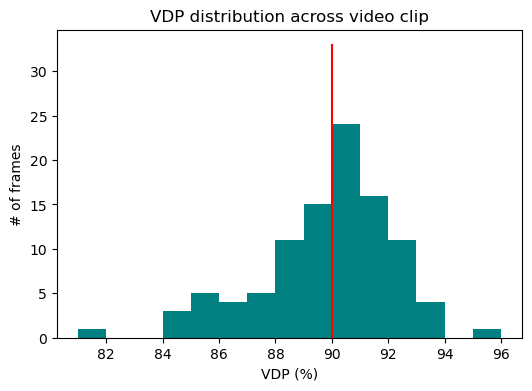

Of your data, 99.0 % is acceptable.
Of your data, 0.0 % is really worrying.


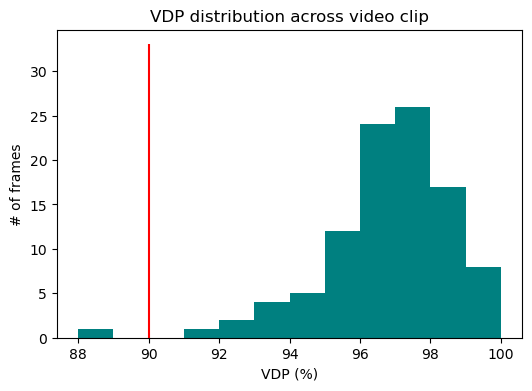

Of your data, 0.0 % is acceptable.
Of your data, 10.0 % is really worrying.


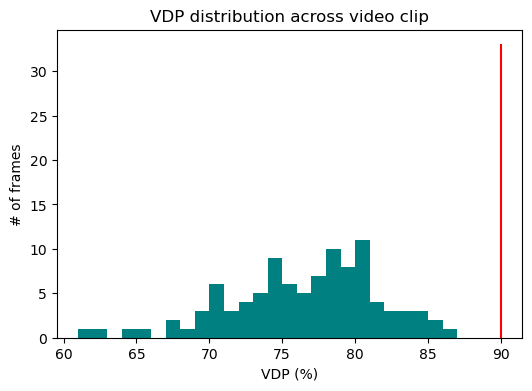

In [197]:
#medium
histogramVDP("C:/Users/oksan/Downloads/SSR 2026/PIVlab Testing and Training/Tester Files for Validation/control_t1_f100_2pass_med/control_t1_f100_2pass_med_","C:/Users/oksan/Downloads/SSR 2026/PIVlab Testing and Training/Tester Files for Validation/filtered_t1_f100_2pass_med/filtered_t1_f100_2pass_med_", 100)

#large
histogramVDP("C:/Users/oksan/Downloads/SSR 2026/PIVlab Testing and Training/Tester Files for Validation/control_t1_2pass_large/control_t1_2pass_large_","C:/Users/oksan/Downloads/SSR 2026/PIVlab Testing and Training/Tester Files for Validation/filtered_t1_2pass_large/filtered_t1_2pass_large_", 100)

#t5 small
histogramVDP("C:/Users/oksan/Downloads/SSR 2026/PIVlab Testing and Training/Tester Files for Validation/control_t5_2pass_small/control_t5_2pass_small_","C:/Users/oksan/Downloads/SSR 2026/PIVlab Testing and Training/Tester Files for Validation/filtered_t5_2pass_small/filtered_t5_2pass_small_", 100)

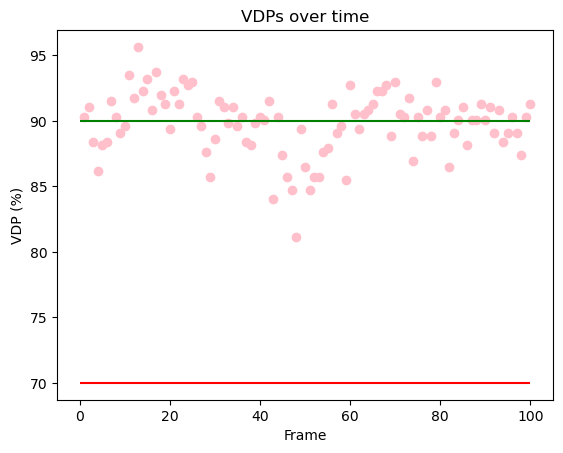

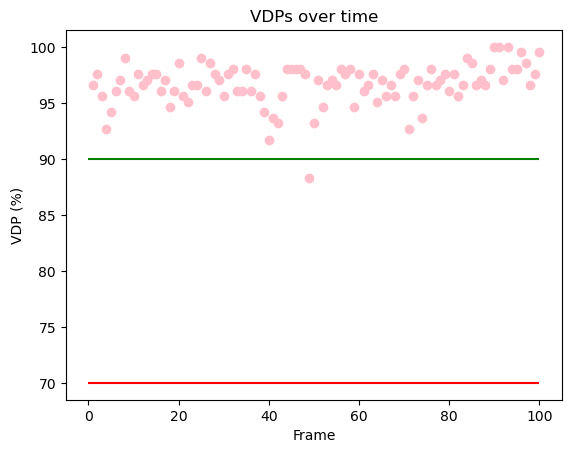

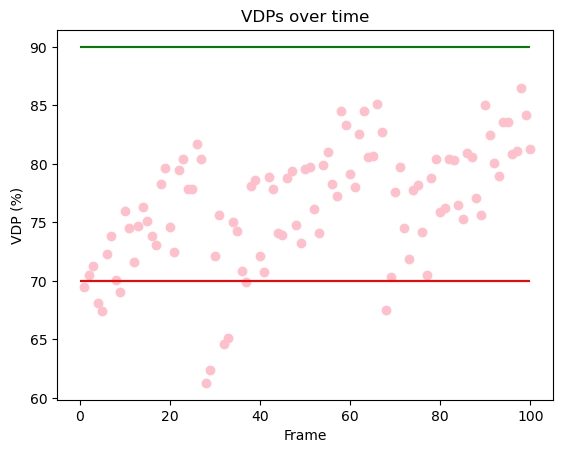

Caution! The following data is below 80!
69.5141065830721 %, frame 0
70.53291536050156 %, frame 1
71.23824451410658 %, frame 2
68.10344827586206 %, frame 3
67.39811912225704 %, frame 4
72.33542319749216 %, frame 5
73.82445141065831 %, frame 6
70.0626959247649 %, frame 7
69.04388714733543 %, frame 8
76.01880877742947 %, frame 9
74.52978056426332 %, frame 10
71.63009404388715 %, frame 11
74.68652037617555 %, frame 12
76.33228840125392 %, frame 13
75.15673981191222 %, frame 14
73.82445141065831 %, frame 15
73.04075235109718 %, frame 16
78.29153605015674 %, frame 17
79.62382445141067 %, frame 18
74.60815047021944 %, frame 19
72.4921630094044 %, frame 20
79.46708463949844 %, frame 21
77.89968652037618 %, frame 23
77.89968652037618 %, frame 24
61.28526645768025 %, frame 27
62.38244514106584 %, frame 28
72.10031347962382 %, frame 29
75.62695924764891 %, frame 30
64.57680250783699 %, frame 31
65.12539184952978 %, frame 32
75.07836990595611 %, frame 33
74.29467084639498 %, frame 34
70.846394984

In [198]:
#medium
findWeirdos("C:/Users/oksan/Downloads/SSR 2026/PIVlab Testing and Training/Tester Files for Validation/control_t1_f100_2pass_med/control_t1_f100_2pass_med_","C:/Users/oksan/Downloads/SSR 2026/PIVlab Testing and Training/Tester Files for Validation/filtered_t1_f100_2pass_med/filtered_t1_f100_2pass_med_", 100)

#large
findWeirdos("C:/Users/oksan/Downloads/SSR 2026/PIVlab Testing and Training/Tester Files for Validation/control_t1_2pass_large/control_t1_2pass_large_","C:/Users/oksan/Downloads/SSR 2026/PIVlab Testing and Training/Tester Files for Validation/filtered_t1_2pass_large/filtered_t1_2pass_large_", 100)

#t5 small
findWeirdos("C:/Users/oksan/Downloads/SSR 2026/PIVlab Testing and Training/Tester Files for Validation/control_t5_2pass_small/control_t5_2pass_small_","C:/Users/oksan/Downloads/SSR 2026/PIVlab Testing and Training/Tester Files for Validation/filtered_t5_2pass_small/filtered_t5_2pass_small_", 100)